# **Online Learning Engagement Dataset**

*This dataset represents student engagement and learning behavior in an online education environment. It includes various features related to student demographics, study habits, platform activity, and academic performance.*

*Key variables include student login frequency, study hours, video watch time, assignment submissions, quiz attempts, and engagement metrics. These features help capture how students interact with digital learning platforms.*

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import binom
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#read the dataset
df=pd.read_csv("/kaggle/input/datasets/utopiasomeone/learning/download.csv")

# **Data Preparation: Exploring & Cleaning the dataset**

In [4]:
df.sample(5)
# view a random summary of data

,learner_id,gender,age,education_level,course_type,learning_mode,region,device_type,study_hours_per_week,videos_watched,forum_posts,assignments_completed_score,quiz_score,engagement_score,final_score,participation_level,completion_status,performance_category
3178,LRN03179,Male,29.0,High School,Programming,Blended,Alexandria,Laptop,5.8,25 videos,4,71.2,88.5,72.0,62.361424,High,Completed,Good
3524,LRN03525,Male,30.0,Professional,Design,Self-paced,Giza,Mobile,3.5,15 videos,1,59.2,69.5,32.6,46.748111,Low,Not Completed,Needs Support
167,LRN00168,Female,28.0,Undergraduate,Design,Blended,Cairo,Laptop,9.5,31 videos,4,54.5,65.0,67.0,60.501857,High,Completed,Good
513,LRN00514,Female,29.0,Graduate,Business,Self-paced,Giza,Laptop,6.3,21 videos,2,63.1,67.5,50.7,57.288440,Medium,Not Completed,Good
4620,LRN04621,Male,34.0,Professional,Data Analysis,Self-paced,Cairo,Laptop,8.4,23 videos,3,78.8,60.7,59.8,61.843969,Medium,Completed,Good


In [5]:
df.shape
# output format = (rows , cols)

(5010, 18)

In [6]:
df.info()
# check names of columns to understand data more and check naming consistency ✅
# check null values number  (missing values detected) ⚠️
# check data types - 'videos_watched' stored as object (contains text) ❌

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   learner_id                   5010 non-null   object 
 1   gender                       5010 non-null   object 
 2   age                          5000 non-null   float64
 3   education_level              5010 non-null   object 
 4   course_type                  5010 non-null   object 
 5   learning_mode                5010 non-null   object 
 6   region                       5010 non-null   object 
 7   device_type                  4998 non-null   object 
 8   study_hours_per_week         5005 non-null   float64
 9   videos_watched               5010 non-null   object 
 10  forum_posts                  5010 non-null   int64  
 11  assignments_completed_score  5010 non-null   float64
 12  quiz_score                   5010 non-null   float64
 13  engagement_score  

In [7]:
# Missing Values Solution

# replacing any missing val with the median not the mean (as it's affected heavily with any outliers)
age_median = df['age'].median()
df['age'] = df['age'].fillna(age_median)

# replacing missing device with the most repeated one because it's categorial
device_mode = df['device_type'].mode()[0]
df['device_type'] = df['device_type'].fillna(device_mode)

# replacing any missing val with the median not the mean (as it's affected heavily with any outliers)
hours_median = df['study_hours_per_week'].median()
df['study_hours_per_week'] = df['study_hours_per_week'].fillna(hours_median)

In [8]:
# Cleaning videos_watched column from any text value
df['videos_watched'] = df['videos_watched'].str.replace(' videos', '').astype(int)

In [9]:
df.duplicated().sum()
# There are 10 duplicated rows that ruin our results

np.int64(10)

In [10]:
# remove duplicates and recheck
df.drop_duplicates(inplace = True)
df.duplicated().sum()

np.int64(0)

In [11]:
# making sure any missing value was cleaned
df.isnull().sum().sum()

np.int64(0)

In [12]:
df.describe()
# statistical overview ✅
# No negative or weird values detected in important numeric columns
# All values fall within logical ranges

,age,study_hours_per_week,videos_watched,forum_posts,assignments_completed_score,quiz_score,engagement_score,final_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,27.095200,6.804440,21.728000,3.660800,69.865160,76.700880,67.653060,63.346795
std,6.690164,3.089379,7.033656,2.171517,16.485582,14.305572,19.614123,14.827498
min,16.000000,1.000000,0.000000,0.000000,16.900000,27.700000,1.800000,10.967643
25%,22.000000,4.600000,17.000000,2.000000,58.300000,66.500000,54.200000,53.004325
50%,27.000000,6.800000,22.000000,3.000000,70.400000,77.500000,69.100000,64.084110
75%,32.000000,8.900000,26.000000,5.000000,81.900000,87.400000,82.125000,74.047340
max,53.000000,18.500000,45.000000,15.000000,100.000000,100.000000,100.000000,100.000000


# Data Quality Verification

**Observation:**
Missing values and Duplictaes were detected. There was a datatype mismatch in 'videos_watched'. Otherwise, values seemed logical and fall within logical range.

**Procedure:**
I replaced missing values in 'age' and 'study_hours_per_week' with the median because it's not like mean that is influenced highly by outliers and most probably to be close to the missing value and replaced device_type with the mode as it's categorial value. I removed duplicates to keep results accurate.

# *Variable classification & Descriptive statistics*

### Variable Guide

| Variable Name | Data Type & Subtype | Variable Group | Dataset Element | Related Columns for Insights & Charts |
| :--- | :--- | :--- | :--- | :--- |
| `learner_id` | Categorical (Nominal) | Identifier | Identifier | `completion_status`, `final_score` (For counting) |
| `gender` | Categorical (Nominal) | Learner profile | Main comparison fields | `study_hours_per_week`, `final_score` |
| `age` | Numeric (Discrete) | Learner profile | Main comparison fields | `final_score`, `completion_status` |
| `education_level` | Categorical (Nominal) | Learner profile | Main comparison fields | `quiz_score`, `completion_status` |
| `course_type` | Categorical (Nominal) | Course context | Main comparison fields | `completion_status`, `final_score` |
| `learning_mode` | Categorical (Nominal) | Course context | Main comparison fields | `engagement_score`, `completion_status` |
| `region` | Categorical (Nominal) | Learner profile | Main comparison fields | `device_type`, `completion_status` |
| `device_type` | Categorical (Nominal) | Course context | Main comparison fields | `study_hours_per_week`, `completion_status` |
| `study_hours_per_week` | Numeric (Continuous) | Study behavior | Main behavior fields | `final_score`, `engagement_score` |
| `videos_watched` | Numeric (Discrete) | Study behavior | Main behavior fields | `final_score`, `engagement_score` |
| `forum_posts` | Numeric (Discrete) | Study behavior | Main behavior fields | `final_score`, `engagement_score` |
| `assignments_completed_score` | Numeric (Continuous) | Scores and engagement | Main behavior fields | `final_score`, `engagement_score` |
| `quiz_score` | Numeric (Continuous) | Scores and engagement | Main outcome fields | `final_score`, `completion_status` |
| `engagement_score` | Numeric (Continuous) | Scores and engagement | Main outcome fields | `final_score`, `completion_status` |
| `final_score` | Numeric (Continuous) | Outcomes | Main outcome fields | `study_hours_per_week`, `completion_status` |
| `participation_level` | Categorical (Ordinal) | Outcomes | Main outcome fields | `final_score`, `engagement_score` |
| `completion_status` | Categorical (Nominal/Binary) | Outcomes | Main outcome fields | `engagement_score`, `final_score` |
| `performance_category` | Categorical (Ordinal) | Outcomes | Main outcome fields | `final_score`, `quiz_score` |

### Descriptive Statistics Interpretation

Based on the descriptive statistics shown in the `df.describe()` output above, several key patterns are shown:

**1. Age Distribution:**
- **Mean:** 27.1 years | **Median:** 27 years | **Range:** 16 - 53 years
- Most learners fall within the 22-32 age range (Q1-Q3). This suggests the platform primarily attracts young adults in undergraduate and graduate education. Age does not appear to be a critical performance factor but helps define the target audience.

---

**2. Study Behavior:**

| Variable | Mean | Median | Range | Interpretation |
|----------|------|--------|-------|----------------|
| **Weekly Study Hours** | 6.8 hrs | 6.8 hrs | 1 - 18.5 hrs | The average learner studies about 7 hours per week, with significant variation (from 1 to 18.5 hours). Some learners put in much more effort than others. |
| **Videos Watched** | 21.7 videos | 22 videos | 0 - 45 videos | Mean and median are close (~22 videos), indicating a fairly symmetric distribution. Some learners watched no videos, while others watched over 45. |
| **Forum Posts** | 3.7 posts | 3 posts | 0 - 15 posts | Most learners participate modestly in forums (Q1 = 2 posts). This may indicate that forums are not the primary interaction tool, or learners prefer other communication methods. |

---

**3. Scores and Performance:**

| Variable | Mean | Median | Range | Interpretation |
|----------|------|--------|-------|----------------|
| **Assignment Score** | 69.9% | 70.4% | 16.9% - 100% | Good assignment performance with an average around 70%. High variability (Std = 16.5) indicates a performance gap between learners. |
| **Quiz Score** | 76.7% | 77.5% | 27.7% - 100% | Better performance in quizzes compared to assignments. This may suggest learners prepare better for quizzes, or quizzes are more clearly structured. |
| **Engagement Score** | 67.7% | 69.1% | 1.8% - 100% | Very high variability (Std = 19.6). Some learners have extremely low engagement (1.8%) while others are excellent (100%). This is the most variable indicator in the dataset. |
| **Final Score** | 63.3% | 64.1% | 11% - 100% | Average final score is 63.3% with moderate variability (Std = 14.8). About 25% of learners scored below 53%, while 25% scored above 74%. This suggests opportunities to improve low-performing learners. |

---

**4. Key Insights:**

1. **Performance Correlation:** Learners who perform well on quizzes and assignments tend to achieve higher final scores (as expected).

2. **Engagement Variability:** Engagement scores show the highest variability among learners, indicating that some learners are highly active while others are passive learners.

3. **Improvement Opportunity:** The average final score of 63.3% needs to be improved as it's very low.

4. **Study Behavior:** Weekly study hours and videos watched are the most consistent behavioral indicators, with distributions centered around the mean.

# **Probability, Binomial, and Normal Distribution Analysis**

# *1. Probability Analysis*

In [13]:
print("Question One: What is the probability that a learner completed the course?")
# so this is simple probability question we just need to divide students
# who completed the course by all students
P_completion = df[df['completion_status'] == 'Completed']['learner_id'].count() / df['learner_id'].count()
print(f"Answer: {P_completion:.2%}")
# .2% multiplies by 100 and adds the '%' sign with 2 decimal places by default!

Question One: What is the probability that a learner completed the course?
Answer: 59.66%


***Nearly 3 out of every 5 learners (59.66%) complete the course which is a moderate to high completion rate in online courses that indicates the curriculum is reasonable in terms of simplicity (not 100% pass so it's neither too easy nor too difficult), accessible for the majority and keeps learners engaged. However, 40.34% dropout rate is concerning enough to track a pattern and understand roots of the problem (reasons) to solve it.***

In [14]:
print("Question Two: What is the probability that a learner is in a high participation group?")

# with the same approach in the previous step, I'll divide no of highly participating learners
# by the number of the full cohort to get the probability of finding an active learner
P_high_part = df[df['participation_level'] == 'High']['learner_id'].count() / df['learner_id'].count()

print(f"Answer: {P_high_part:.2%}")
# .2% multiplies by 100 and adds the '%' sign with 2 decimal places by default!

Question Two: What is the probability that a learner is in a high participation group?
Answer: 47.86%


***Approximately 1 out of every 2 learners in the course is a highly commited learner... This rate shows a high level of participation compared to typical online learning platforms. While this is a positive indicator, the remaining 52.14% of learners (Medium/Low participation) suggests an opportunity for targeted strategies to increase completion rates and pulls learners to higher activity after understanding what drives the high-participation group.***

In [15]:
print("Question Three: What is the probability of course completion among learners with high engagement?")
# I'll just calc P by dividing high engagement scorers who completed the course by total high engage learners
# I'll split data by the median to define high vs low engagement scorers
engagement_threshold = df['engagement_score'].median() # used median not mean for the same reason mentioned before
high_engage_learners = df[(df['engagement_score'] > engagement_threshold)] # total high engage learners

# student who are highly engaged and completed the course
completed_high_engage = high_engage_learners[high_engage_learners['completion_status'] == 'Completed']['learner_id'].count()

P_high_engage = completed_high_engage/high_engage_learners['learner_id'].count()
print(f"Answer: {P_high_engage:.2%}")
# .2% multiplies by 100 and adds the '%' sign with 2 decimal places by default!

Question Three: What is the probability of course completion among learners with high engagement?
Answer: 91.90%


***As expected, the rate of course completion among highly engaged learners (91.90%) far exceeds general rate of course completion (59.66%) by 32.24%.***

***This means high engagement is a powerful driver of student success, and it validates that current engagement score formula is highly accurate in predicting course completion. Since highly engaged learners are far more common to finish their courses (nearly 92%!).***

***The platform should focus on keeping the current highly engaging learners and encouraging the remaining cohort to be more active. This can be achieved by designing attractive notifactions system and rewarding engagement with public badges or motivational milestones. By that the completion rate is also expected to be lifted.***

In [16]:
print("Question Four: How does completion probability differ across learning modes?")
# We have three learning modes : Self-paced, Blended, Instructor-led
# I'll simply calc each mode completion probability using groupby

# This simple line will output a series stating learning_mode and probability of completion through each learning_mode
P_mode_comp = df[df['completion_status'] == 'Completed'].groupby('learning_mode')['learner_id'].count() / df.groupby('learning_mode')['learner_id'].count()
# I want to output P on 100 percentage scale so I'll use mapping
formatted_perc = P_mode_comp.map(lambda x: f"{x:.2%}")
formatted_perc

Question Four: How does completion probability differ across learning modes?


learning_mode
Blended           69.28%
Instructor-led    68.27%
Self-paced        47.07%
Name: learner_id, dtype: object

***Completion rates for Blended (69.28%) and Instructor-led (68.27%) modes are nearly identical, suggesting both modes are equally effective. The Self-paced mode shows a visible lower completion rate (47.07%), which indicates that learners in this mode need additional support. Suggested approaches include optional live sessions, progress reminders, or flexible milestone deadlines that provide structure without removing learner autonomy or decreasing flexibility***

# *2. Binomial Distribution Analysis*

**Binomial distribution needs to have fixed values so let's assign them first:**
* P = 0.5966 (probability of completing the course as we calculated previously)
* N = 10 records
* Success when 'completion_status' = 'Completed' (learner finished the course)
* Failure when 'completion_status' = 'Not Completed' (learner failed to finish the course)

**I will apply binomial distributon rules in this analysis to find:**
1. Mean: E(X) = μ = n × p
2. Variance: Var(X) = σ² = n × p × (1−p)
3. Standard Deviation: σ = √(n × p × (1−p))
4. Probability of success of certain number of trials: P(X = k) = C(n,k) × pk × (1−p)n−k

In [17]:
# assigning fixed values
n = 10
p = 0.5966
# storing n and p values into a var not to write them every time
binom_d = binom(n, p)
# using built-in functions to calc easily
mean = binom_d.mean() # average expected number of succesful learners in our sample of 10
std = binom_d.std() # measures spread of number succesful learners around the mean
variance = binom_d.var() # squared std

print(f"Mean (Expected value of successes): {mean:.2f}")
print(f"Standard Deviation: {std:.2f}")
print(f"Variance: {variance:.2f}")

Mean (Expected value of successes): 5.97
Standard Deviation: 1.55
Variance: 2.41


In [18]:
# I'll use Probability Mass Function pmf to calc P that exactly 5 finish the course
prob_mass = binom_d.pmf(5)
print(f"Probability of exactly 5 learners completing: {prob_mass * 100:.2f}%")
# I'll use Cumulative Distribution Function to calc to calc P of 5 or less learners completing (X <= 5)
prob_cumulative = binom_d.cdf(5)
print(f"Probability of 5 or fewer learners completing: {prob_cumulative * 100:.2f}%")
# Probability of 5 or more learners completing (X >= 5)
prob_5_or_more = 1 - binom_d.cdf(4)
print(f"Probability of 5 or more learners completing: {prob_5_or_more * 100:.2f}%")

Probability of exactly 5 learners completing: 20.35%
Probability of 5 or fewer learners completing: 37.54%
Probability of 5 or more learners completing: 82.80%


***With Standard Deviation of 1.55 and Mean 5.97, the number of successful graduates in any random group of 10 will typically vary between 4 and 8 learners. This suggests that the platform should inspect any group of 10 students where completion is 3 or below becuase it likely has technical or design problems. An 82.80% probability that 5 or more learners out of 10 is a reassuring rate for learners to be confident to spend their time on the courses and for the sponsors or partners as well.***

# *3. Normal Distribution and Z-Score analysis*

***Regarding 'final_score', I'll look at its distribution shape, then use Z-Scores to describe whether a value is typical or unusual compared with the rest of the Dataset.***

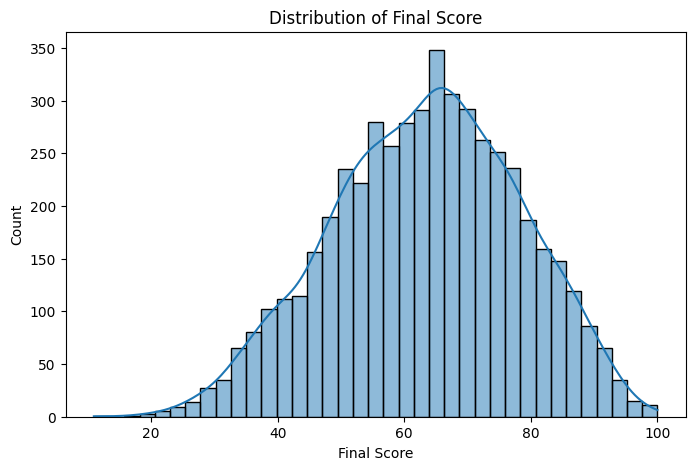

In [19]:
plt.figure(figsize=(8, 5))
# chose to use histogram beacause score is continuous data so histplot will provide spread and shape of the data perfectly
sns.histplot(df['final_score'], kde=True) # kde smooths the histogram into a curve
plt.title('Distribution of Final Score')
plt.xlabel('Final Score')
plt.show()

***The final score distribution is well balanced and represents a Bell Curve, with most learners concentrated around a peak of about 65! While there is a very slight, natural skew to the left, the distribution remains normal. This indicates a highly fair and realistic assessment where extreme scores are rare, and the majority of students sit comfortably in the middle around the mean.***

In [20]:
# Calculating the Mean and Standard Deviation for the final score
# To use them as the reference point for Z-Score interpretation.
mean_grade = df['final_score'].mean()
std_grade = df['final_score'].std()

print(f"Average Score: {mean_grade:.2f}")
print(f"Standard Deviation: {std_grade:.2f}")

Average Score: 63.35
Standard Deviation: 14.83


In [21]:
# Calculate Z-Scores for selected values
df['grade_z_score'] = (df['final_score'] - mean_grade) / std_grade
# Show 3 learners by their index to explain whether their values are 
# typical, high, or low compared with the group.
selected_rows = df.iloc[[1036, 2711, 196]]
selected_rows[['learner_id', 'final_score', 'grade_z_score']]

,learner_id,final_score,grade_z_score
1036,LRN01037,10.967643,-3.532569
2711,LRN02712,63.346174,-0.000042
196,LRN00197,100.000000,2.471975


* Learner with ID 2711 is **typical** as their Z-score [-0.000042] is very close to zero which means it's near the average.
* Learner with ID 196 is extremely **high** as their Z-score exceeds 2! This student is a top-tier.
* Learner with ID 1036 is extremely **low** as their Z-score is well below -2 making his grade the lowest.

# *4. Claim boundary note*

**Probability and Distribution analysis can prove:**
* Description & Comparison: It can describe center, mean and spread of data.
* Identifying Patterns & Outliers: It can output the outliers like in case of the outstanding learner with high score and his struggling peer.
* Probabilistic Expectation: If we pulled a random sample out of the data it can predict the probability based on historical data probabilities.
  
**Probability and Distribution analysis cannot prove:**
* Causation: If a high-grade learner actively engages and has high engagement score this CANNOT prove the engagement score is directly related to the learner's final score.
* Formal Significance: It can predict and describe on this set of data ONLY not new data because it's descriptive not inferential. No formal hypothesis testing was performed to prove statistical significance.

# **Specific Visual Analysis and Evidence Building**

# *1. Univariate visuals*

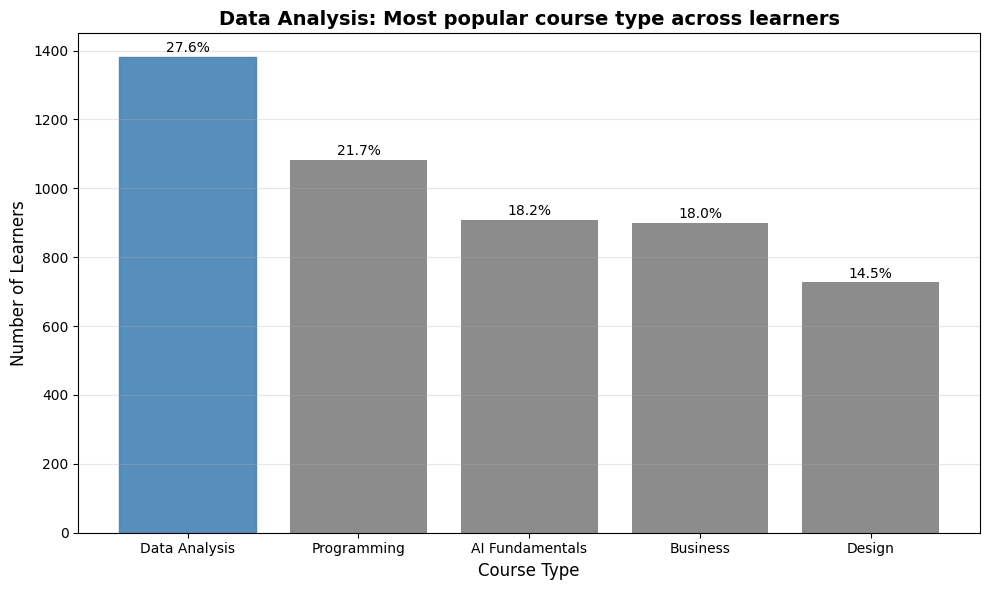

In [22]:
# Univariate Visual 1: Course Type Distribution

# Calculate counts and percentages of course type values
course_counts = df['course_type'].value_counts()
course_percentages = df['course_type'].value_counts(normalize=True) * 100

# Create DataFrame for plotting
course_df = pd.DataFrame({
    'Count': course_counts,
    'Percentage': course_percentages
}).reset_index()
course_df.columns = ['course_type', 'count', 'percentage']

# Sort by count descending for easier reading
course_df = course_df.sort_values('count', ascending=False)

# Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(course_df['course_type'], course_df['count'], color='gray', alpha=0.9 )
# setting the largest bar to a different color to highlight it
bars[0].set_color('steelblue')
# adding percentage labels on top of bars 
for bar, pct in zip(bars, course_df['percentage']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title('Data Analysis: Most popular course type across learners', fontsize=14, weight='bold')
plt.xlabel('Course Type', fontsize=12)
plt.ylabel('Number of Learners', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Univariate Visual 1: Course Type Distribution**

***Data Analysis takes the lead as the platform's most popular course category, at more than a quarter of total enrollments (27.6%). It is followed by Programming (21.7%), while AI Fundamentals and Business keeps a good, similar share of around 18% each. This clear pattern indicates that technical, data-driven skills remain the primary interest of the user base which aligns with market needs.***

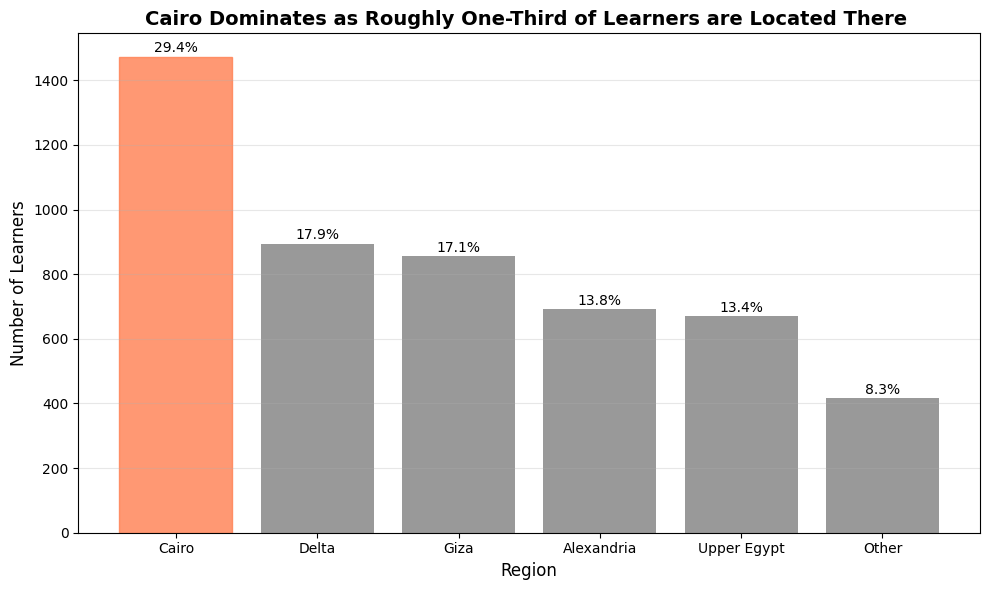

In [23]:
# Univariate Visual 2: Region Distribution (Sorted)
# same approach and steps as the last chart because they are both categorial

region_counts = df['region'].value_counts()
region_percentages = df['region'].value_counts(normalize=True) * 100

region_df = pd.DataFrame({
    'Count': region_counts,
    'Percentage': region_percentages
}).reset_index()
region_df.columns = ['region', 'count', 'percentage']
region_df = region_df.sort_values('count', ascending=False)

# Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(region_df['region'], region_df['count'], color='gray', alpha=0.8)
bars[0].set_color('coral')

for bar, pct in zip(bars, region_df['percentage']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title('Cairo Dominates as Roughly One-Third of Learners are Located There ', fontsize=14, weight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Learners', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Univariate Visual 2: Region Distribution**

***Geographical analysis shows that the platform successfully reached Egypt's main regions with Cairo dominating the platform with nearly one-third (29.4%) of the entire student base. The remaining learners are distributed in a balanced manner across the Delta (17.9%), Giza (17.1%), Alexandria (13.8%), and Upper Egypt (13.4%).***

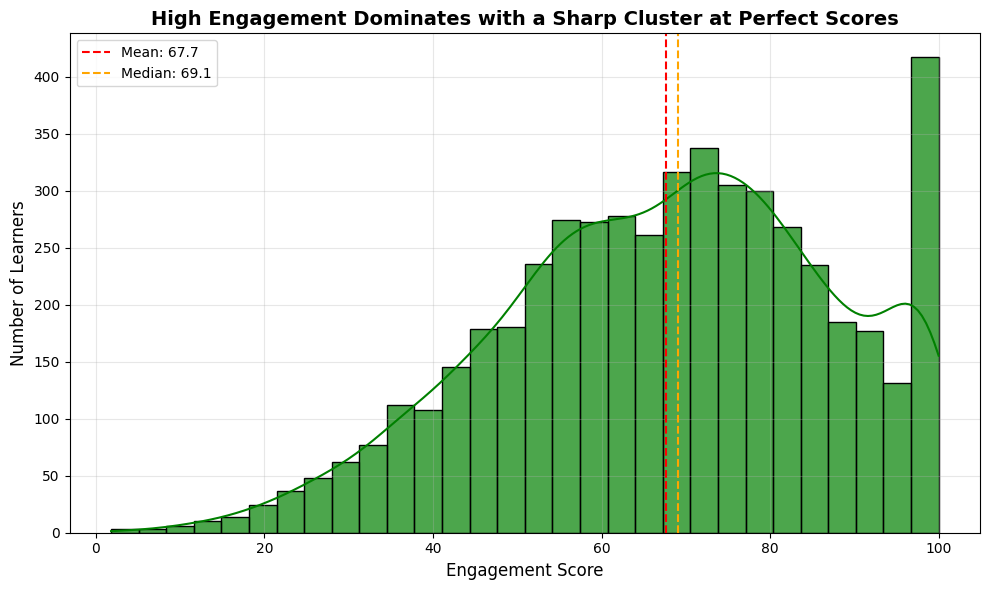

In [24]:
# Univariate Visual 3: Engagement Score Distribution

plt.figure(figsize=(10, 6))

# Histogram with KDE because it's continuous and KDE shows the clean shape in a curve
sns.histplot(df['engagement_score'], kde=True, bins=30, color='green', alpha=0.7)

# Add vertical lines for mean and median to highlight them
mean_engagement = df['engagement_score'].mean()
median_engagement = df['engagement_score'].median()
plt.axvline(mean_engagement, color='red', linestyle='--', 
            label=f'Mean: {mean_engagement:.1f}')
plt.axvline(median_engagement, color='orange', linestyle='--', 
            label=f'Median: {median_engagement:.1f}')

plt.title('High Engagement Dominates with a Sharp Cluster at Perfect Scores', fontsize=14, weight='bold')
plt.xlabel('Engagement Score', fontsize=12)
plt.ylabel('Number of Learners', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Univariate Visual 3: Engagement Score Distribution**

***The engagement score distribution exhibits a desired left skew, indicating that the majority of learners are highly active, with the typical student maintaining a median score of 69.1. Most notably, a massive cluster of over 400 learners achieved a perfect score of 100%, showing a group of frequent users who represent the peak of continuous platform interaction.***

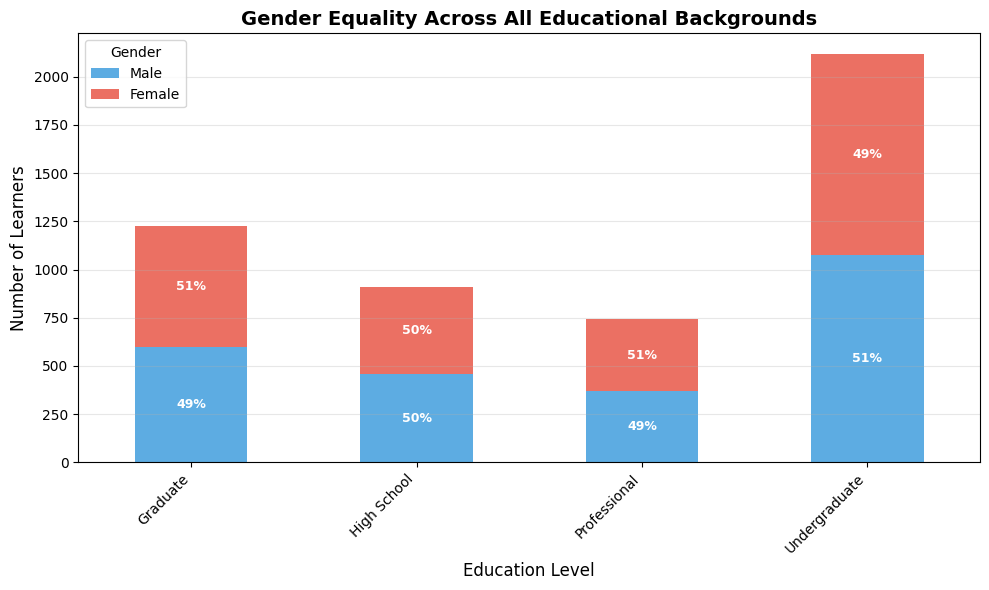

In [25]:
# Univariate Visual 4: Education Level by Gender (Stacked Bar)

# Create table of every female and male in their education level
edu_gender = pd.crosstab(df['education_level'], df['gender'])

# Plot stacked bar with blue for male and red for female, alpha = 0.8 to avoid very strong irritating colors
ax = edu_gender.plot(kind='bar', stacked=True, figsize=(10, 6), 
                     color=['#3498db', '#e74c3c'], alpha=0.8)

# Add percentage labels on bars
totals = edu_gender.sum(axis=1)
for i, (idx, row) in enumerate(edu_gender.iterrows()):
    cumsum = 0
    for gender in edu_gender.columns:
        value = row[gender]
        if value > 0:
            percentage = (value / totals.iloc[i]) * 100
            ax.text(i, cumsum + value/2, f'{percentage:.0f}%', 
                    ha='center', va='center', fontsize=9, color='white', weight='bold')
        cumsum += value

plt.title('Gender Equality Across All Educational Backgrounds', fontsize=14, weight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Number of Learners', fontsize=12)
plt.legend(title='Gender', labels=['Male', 'Female'])

# rotates education levels for easier reading  
plt.xticks(rotation=45, ha='right')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Univariate Visual 4: Education Level by Gender**

***The stacked bar chart reveals an outstanding balance in gender distribution across all educational levels, with a nearly perfect 50/50 split between male and female learners in each category. This strongly suggests that the platform provides equal learning opportunities and has equal appeal for both genders, regardless of their academic qualifications.***

# *2. Business-question visuals*

In [26]:
# First Business Question: Which course type has the highest completion rate?

# create a completed column to filter course-type who completed easily
df['completed'] = df['completion_status']=='Completed'
completion_by_course = df.groupby('course_type')['completed'].mean().sort_values(ascending=False).reset_index()
# converting rates to 100 percentage scale for easier reading
completion_by_course['completion_rate_%'] = completion_by_course['completed'] * 100
completion_by_course['completion_rate_%'] # seeing results before visualizing

0    61.485557
1    60.946095
2    59.095106
3    58.870384
4    58.777778
Name: completion_rate_%, dtype: float64

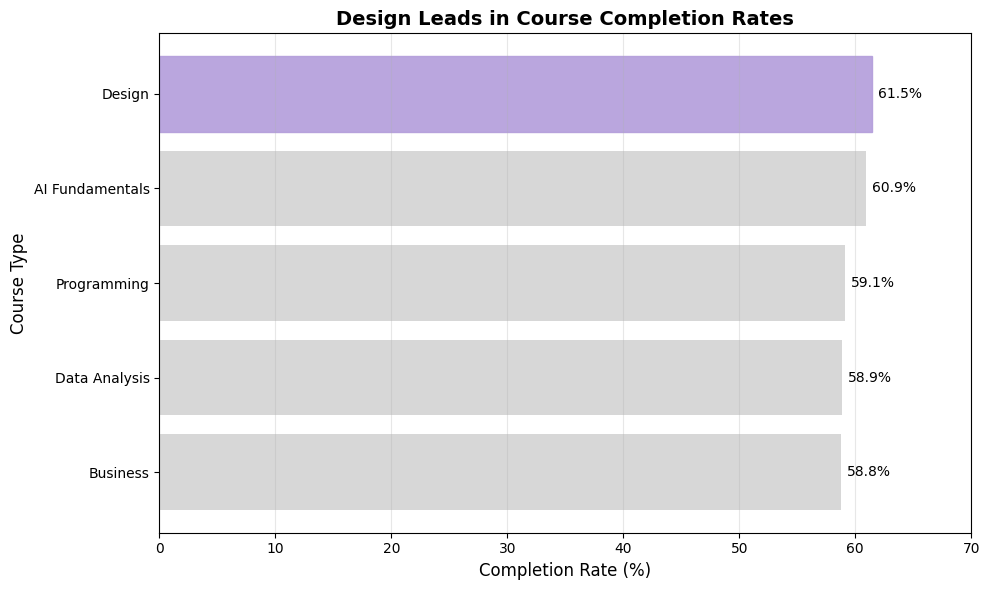

In [27]:
# First Business Question: Which course type has the highest completion rate?

# Create a completed column
df['completed'] = df['completion_status'] == 'Completed'

# Calculate completion rate by course type
completion_by_course = df.groupby('course_type')['completed'].mean().reset_index()
completion_by_course['completion_rate_%'] = completion_by_course['completed'] * 100

# Sorting values for eye comfort and faster understanding
completion_by_course = completion_by_course.sort_values('completion_rate_%', ascending=True)

# Horizontal bar chart for easier reading due to long course names and because the two variables are categorial
plt.figure(figsize=(10, 6))

bars = plt.barh(completion_by_course['course_type'], 
                completion_by_course['completion_rate_%'],
                color='lightgray', alpha=0.9)

# highlighting the highest completion rate with light purple
bars[-1].set_color('#b39ddb')

# Add percentage labels to show more about data
for bar in bars:
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height()/2
    plt.text(width + 0.5, y_pos, f'{width:.1f}%', ha='left', va='center', fontsize=10)

plt.title('Design Leads in Course Completion Rates', fontsize=14, weight='bold')
plt.xlabel('Completion Rate (%)', fontsize=12)
plt.ylabel('Course Type', fontsize=12)
plt.xlim(0, 70)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Evidence-Based Observations: Course-type Completion Rates

***To my surprise, Design courses take the lead with the highest completion rate at 61.5%, closely followed by AI Fundamentals at 60.9%! What makes this finding truly fascinating is that while Design had the lowest enrollment rate overall, its learners are clearly the most committed to crossing the finish line. Meanwhile, the most popular categories like Programming and Data Analysis still hold stable completion rates of around 59%.***

**Business & Content Insight:**

***This proves that subjects like Design and AI have remarkable student attention until the end. The platform should analyze the curriculum structure of the Design courses to see why they keep students hooked, if it's highly interactive or visually engaging or any reason that raised completion rates, designers should replicate those successful elements in the high-enrollment courses to help push total completion rates higher!***

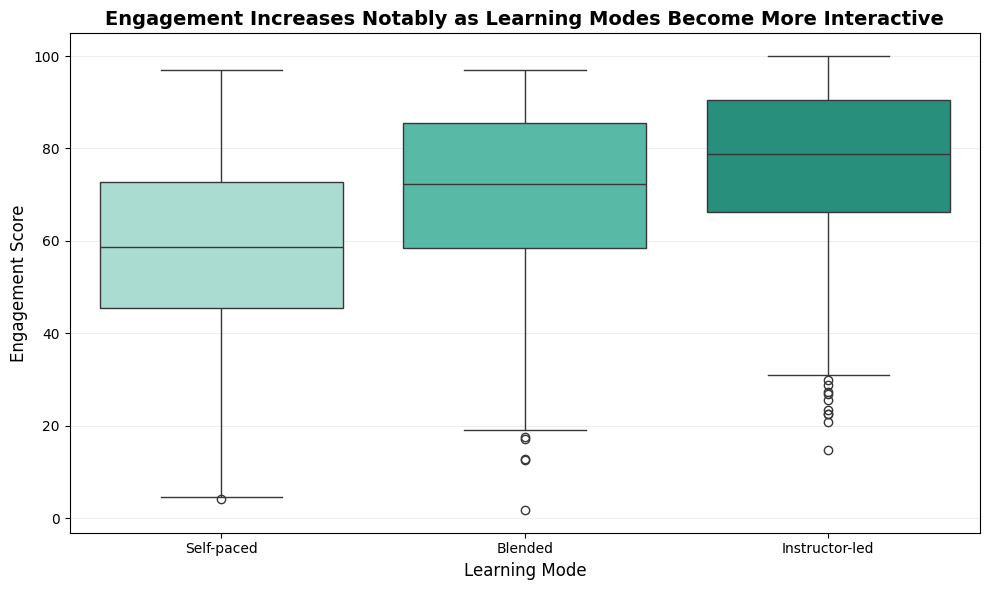

,mean,median,std
learning_mode,,,
Blended,71.2,72.3,17.7
Instructor-led,77.3,78.8,16.8
Self-paced,58.7,58.8,18.7


In [28]:
# Second Question: How does engagement differ across learning modes?


# Box plot for engagement across learning modes as variables are categorial and numerical 
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='learning_mode', y='engagement_score', hue = 'learning_mode', legend = False,
            palette=['#48c9b0', '#a3e4d7', '#16a085'], order=['Self-paced', 'Blended', 'Instructor-led'])

plt.title('Engagement Increases Notably as Learning Modes Become More Interactive', fontsize=14, weight='bold')
plt.xlabel('Learning Mode', fontsize=12)
plt.ylabel('Engagement Score', fontsize=12)
plt.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

# Show summary statistics for accuracy
engagement_summary = df.groupby('learning_mode')['engagement_score'].agg(['mean', 'median', 'std']).round(1)
engagement_summary

### Evidence-Based Observations: Engagement Across Learning Modes

***As we compare engagement scores across learning modes, there is a very clear jump in student engagement as we move from self-paced to more interactive environments! While Self-paced courses have a median engagement of 58.8, Blended learning increase it to 72.3, and Instructor-led courses dominate with a higher median score of 78.8.***

***The Human Element is Key:***

*The data sends a powerful message to the course designers: live interaction is the strongest engagement tool. Even though self-paced courses are highly flexible and popular, adding hybrid or blended elements (like weekly live sessions or peer discussions) could be a great opportunity to improve the engagement of self-paced learners and keep them from leaning to lower scores.*

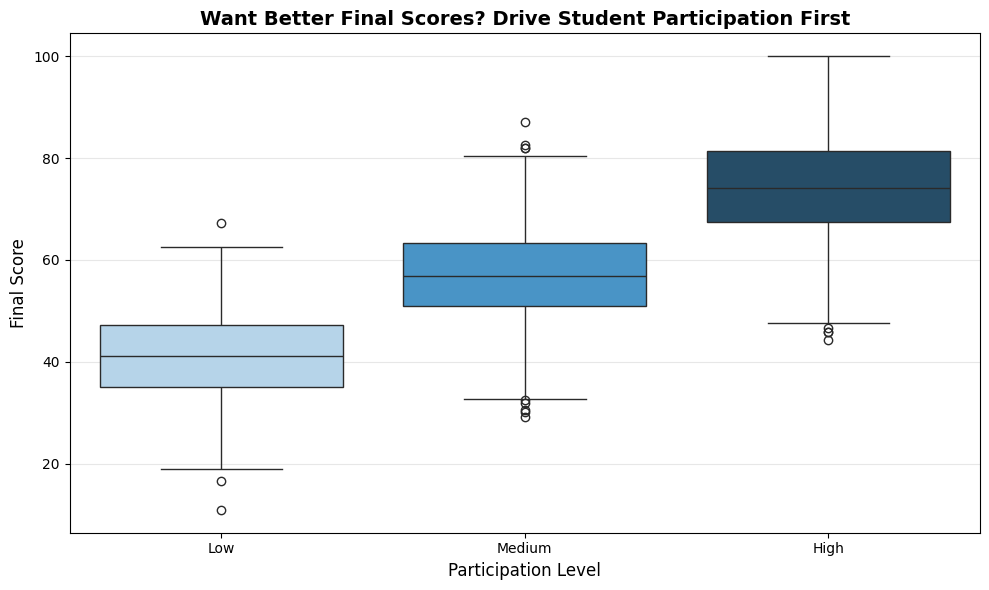

                     mean  median
participation_level              
High                 74.4    74.1
Low                  41.2    41.2
Medium               56.9    56.9


In [29]:
# Business Question 3: How does final score vary by participation level?

# Final score by participation level in order
participation_order = ['Low', 'Medium', 'High']

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='participation_level', y='final_score', hue = 'participation_level', legend = False,
            order=participation_order, palette=['#1b4f72', '#3498db', '#aed6f1'])

plt.title('Want Better Final Scores? Drive Student Participation First', fontsize=14, weight='bold')
plt.xlabel('Participation Level', fontsize=12)
plt.ylabel('Final Score', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Summary statistics for accuracy
participation_summary = df.groupby('participation_level')['final_score'].agg(['mean', 'median']).round(1)
print(participation_summary)

### Evidence-Based Observations: Final score by participation level

***There is a direct link between how much a learner participates and the final score they achieve. Students with Low participation struggle to pass, staying at a median score of around 41. However, once participation levels up to Medium, the median final score jumps to 57, and it absolutely peaks at 74 for High-participation learners.***

**The Business Takeaway:**
***This is a golden insight for platform design. It shouldn't just focus on making students finish the materials it should create interactions to pull passive learners from 'Low' to at least 'Medium' participation, which is a big factor in helping them pass the courses!***

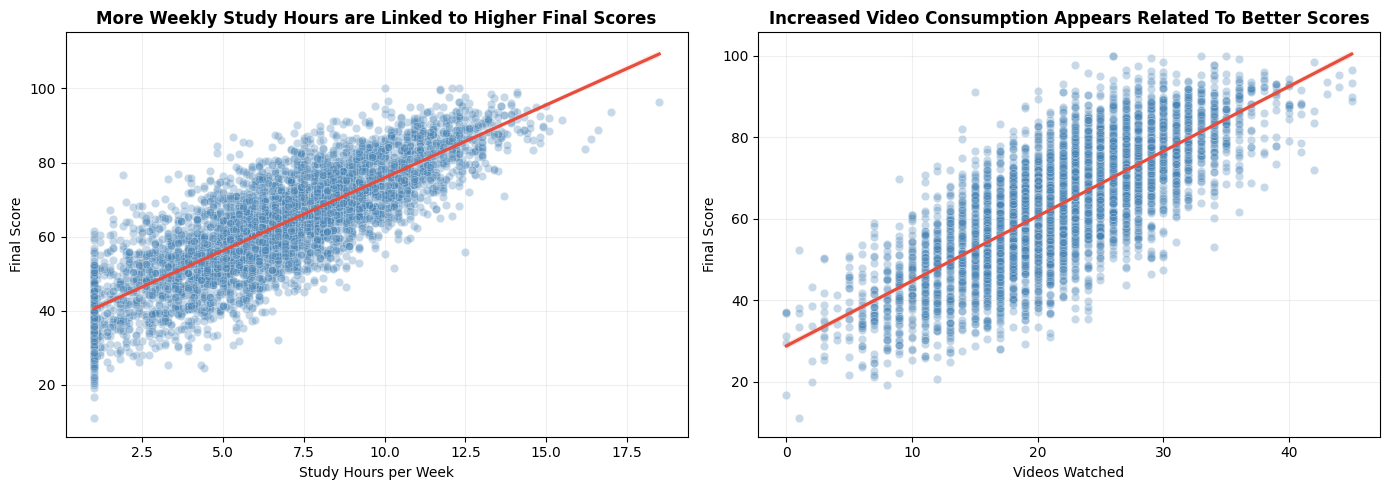

In [30]:
# Business Question 4: Is study behavior related to final performance?

plt.figure(figsize=(14, 5))

# 1. Study Hours vs Final Score
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='study_hours_per_week', y='final_score', alpha=0.3, color='steelblue')
sns.regplot(data=df, x='study_hours_per_week', y='final_score', scatter=False, color='#e74c3c')

plt.title('More Weekly Study Hours are Linked to Higher Final Scores', fontsize=12, weight='bold')
plt.xlabel('Study Hours per Week', fontsize=10)
plt.ylabel('Final Score', fontsize=10)
plt.grid(True, alpha=0.2)

# 2. Videos Watched vs Final Score
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='videos_watched', y='final_score', alpha=0.3, color='steelblue')
sns.regplot(data=df, x='videos_watched', y='final_score', scatter=False, color='#e74c3c')

plt.title('Increased Video Consumption Appears Related To Better Scores', fontsize=12, weight='bold')
plt.xlabel('Videos Watched', fontsize=10)
plt.ylabel('Final Score', fontsize=10)
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

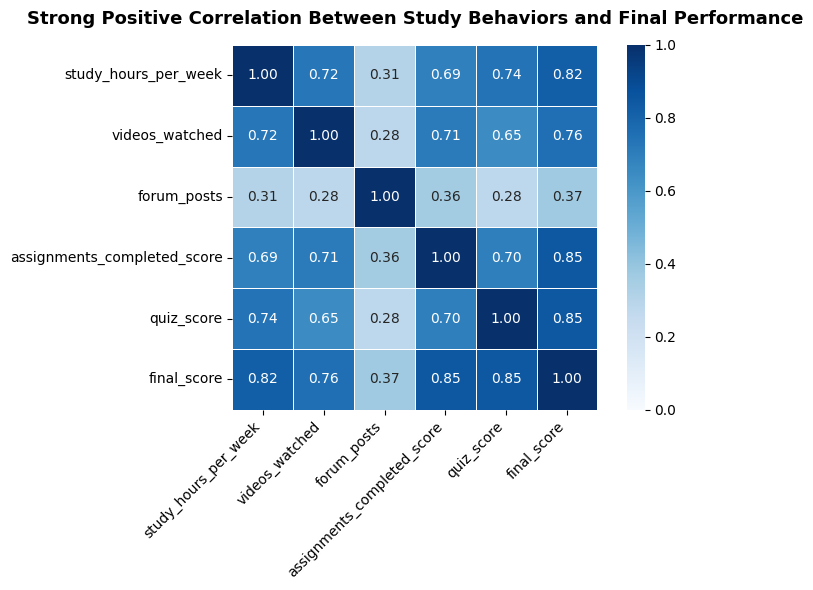

In [31]:
# Create the correlation matrix for study behaviors and performance
behaviors_corr = df[['study_hours_per_week', 'videos_watched', 'forum_posts', 
                     'assignments_completed_score', 'quiz_score', 'final_score']].corr()

# Plotting the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(behaviors_corr, annot=True, fmt=".2f", cmap='Blues', 
            vmin=0, vmax=1, cbar=True, square=True, linewidths=0.5)

plt.title('Strong Positive Correlation Between Study Behaviors and Final Performance', 
          fontsize=13, weight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Evidence-Based Observations: Study Behaviour effect on final score

***Both the scatter plots and correlation heatmap point to: there is a strong, positive relationship between all monitored study behaviors and students' final performance. As weekly study hours, videos watched, forum posts, quiz scores, and completed assignments increase, final scores consistently increase. While these visuals and numbers clearly show that higher study engagement strongly goes hand-in-hand with higher final scores, this correlation does not prove a direct causal relationship.***

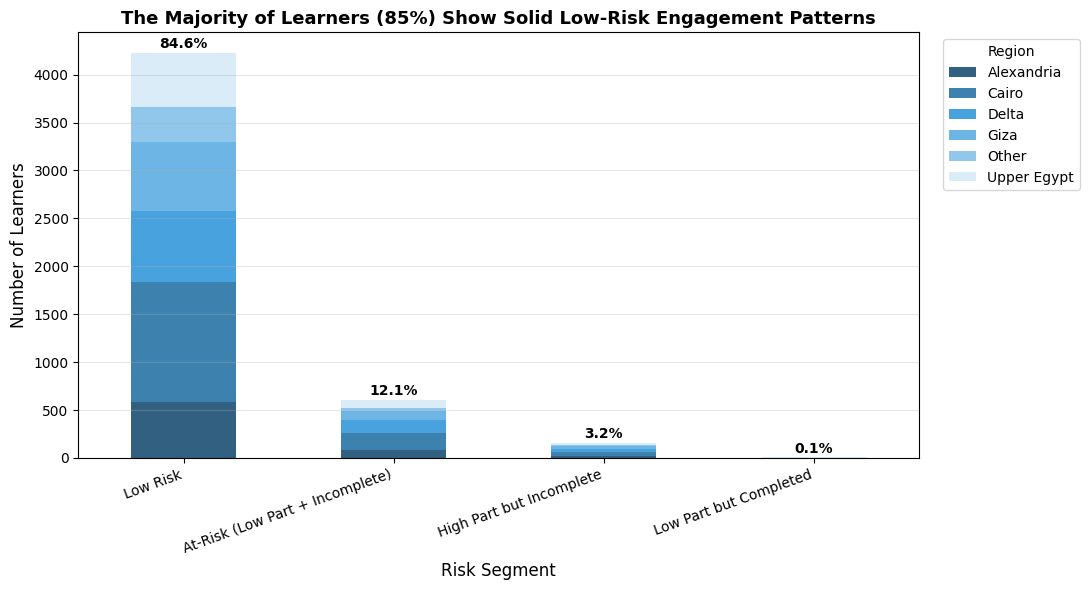

In [32]:
# Business Question 5: Which learner segments may need support?

# at-risk segments logic: Low participation + Not Completed + Low performance

# Create risk categories
def risk_category(row):
    if row['participation_level'] == 'Low' and row['completion_status'] == 'Not Completed':
        return 'At-Risk (Low Part + Incomplete)'
    elif row['participation_level'] == 'Low' and row['completion_status'] == 'Completed':
        return 'Low Part but Completed'
    elif row['participation_level'] == 'High' and row['completion_status'] == 'Not Completed':
        return 'High Part but Incomplete'
    else:
        return 'Low Risk'
# create a new column 'risk_segment'
df['risk_segment'] = df.apply(risk_category, axis=1)

# Count and percentage
risk_counts = df['risk_segment'].value_counts()
risk_pct = df['risk_segment'].value_counts(normalize=True) * 100

risk_df = pd.DataFrame({
    'Count': risk_counts,
    'Percentage': risk_pct
}).reset_index()
risk_df.columns = ['Risk Segment', 'Count', 'Percentage']

# create a risk distribution in each region table
risk_region_table = pd.crosstab(df['risk_segment'], df['region'])
# Sort values for better display
risk_region_table = risk_region_table.reindex(risk_df['Risk Segment'])

# making the colors gradient for eye comfort
blue_gradient = ['#1b4f72', '#2874a6', '#3498db', '#5dade2', '#85c1e9', '#d6eaf8']

# Bar chart
plt.figure(figsize=(11, 6))

ax = risk_region_table.plot(kind='bar', stacked=True, color=blue_gradient, alpha=0.9, ax=plt.gca())

# Adding perecntages for accuracy
for i, (idx, row) in enumerate(risk_df.iterrows()):
    total_val = row['Count']
    pct = row['Percentage']
    plt.text(i, total_val + 15, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, weight='bold')

plt.title('The Majority of Learners (85%) Show Solid Low-Risk Engagement Patterns', fontsize=13, weight='bold')
plt.xlabel('Risk Segment', fontsize=12)
plt.ylabel('Number of Learners', fontsize=12)
plt.xticks(rotation=20, ha='right')

plt.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Evidence-Based Observations: Risk Segment Analysis

* **Dominant Low-Risk Patterns:** The stacked bar chart indicates that the majority of learners (**84.6%**) fall into the **"Low Risk"** category. This visual comparison suggests that overall platform engagement and completion patterns are highly stable for the overwhelming majority of the user base.
* **Proportional Regional Distribution:** A visual comparison of the regional color stacks (representing Cairo, Alexandria, Giza, Delta, Upper Egypt, and Other) shows a highly consistent distribution across both the "Low Risk" and "At-Risk" segments. This pattern suggests that a learner's geographic region is likely not a primary driver of risk, as the regional proportions in the **12.1%** "At-Risk" segment closely mirror those of the "Low Risk" segment.
* **Specific Support Areas:** The chart highlights that the primary group of concern is the **"At-Risk (Low Part + Incomplete)"** segment at **12.1%**. In contrast, the "High Part but Incomplete" (**3.2%**) and "Low Part but Completed" (**0.1%**) segments represent very tiny ratio of the full cohort.

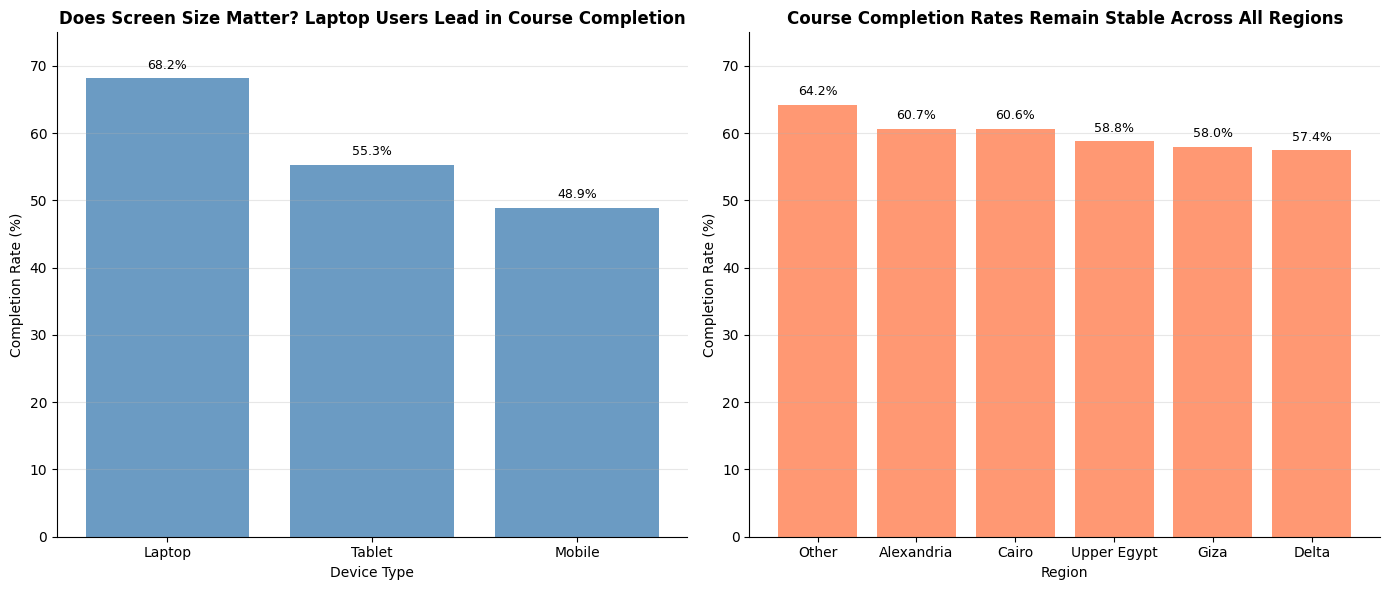

In [33]:
# Business Question 6: How do device type or region relate to completion patterns?

# Device type vs Completion
device_completion = (df.groupby('device_type')['completed']
                       .mean()
                       .sort_values(ascending=False)
                       .reset_index())
device_completion['completion_rate_%'] = device_completion['completed'] * 100

# Region vs Completion
region_completion = (df.groupby('region')['completed']
                       .mean()
                       .sort_values(ascending=False)
                       .reset_index())
region_completion['completion_rate_%'] = region_completion['completed'] * 100

# Figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Device chart
bars1 = axes[0].bar(device_completion['device_type'], 
                    device_completion['completion_rate_%'],
                    color='steelblue', alpha=0.8)

# Clean design: removing top and right borders
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[0].set_title('Does Screen Size Matter? Laptop Users Lead in Course Completion', fontsize=12, weight='bold')
axes[0].set_xlabel('Device Type', fontsize=10)
axes[0].set_ylabel('Completion Rate (%)', fontsize=10)
axes[0].set_ylim(0, 75) 
axes[0].grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, height + 1,
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Region chart
bars2 = axes[1].bar(region_completion['region'], 
                    region_completion['completion_rate_%'],
                    color='coral', alpha=0.8)

# Clean design: removing top and right borders
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

axes[1].set_title('Course Completion Rates Remain Stable Across All Regions', fontsize=12, weight='bold')
axes[1].set_xlabel('Region', fontsize=10)
axes[1].set_ylabel('Completion Rate (%)', fontsize=10)
axes[1].set_ylim(0, 75) 
axes[1].grid(True, alpha=0.3, axis='y')

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, height + 1,
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Evidence-Based Observations: Device & Regional Completion Patterns
Clear Completion Difference by Device: The visual comparison of the device type chart suggests that course completion rates differ notably depending on how learners access the platform. Laptop users lead with a 68.2% completion rate, which is higher than tablet users (55.3%) and mobile users (48.9%). While this visual pattern indicates that larger screens or desktop environments are associated with higher completion, this evidence alone does not prove that the device type itself directly causes a student to complete the course.

Highly Consistent Regional Successs: Completion rates remain notably similar across Egypt, with only tiny variations ranging from Giza (58.0%) and Delta (57.4%) up to Cairo (60.6%) and Alexandria (60.7%). This highly stable pattern indicates that the platform's reach is equally effective and consistent regardless of the learner's location.

# *3. Dashboard candidate selection*

# 🎯 Dashboard Candidate Selection: Strategic Visuals & KPIs

To build a dashboard that serves as a decision tool rather than just a gallery of charts, I selected a highly refined set of visuals that immediately direct stakeholders to successful decisions.

---

### Part 1: Top-Level KPI Cards (Simplified & Action-Oriented)
Instead of forcing the viewer to decode raw decimals, the top-level KPIs are expressed in natural, easy-to-digest formats:
* **Total Learners (5,000 Students):** Establishes the scale of the user base.
* **Overall Completion Rate (3 in 5 Students):** Represents the ~60% target benchmark in a human ratio.
* **Average Engagement (6.8 / 10):** A clear daily baseline of student interaction.
* **Average Final Score (63.3%):** The academic benchmark for cohort success.

---

### Part 2: Selected Visuals & Why They Made the Cut

We structured the layout with **two major high-level charts** on top and **three tactical charts** below to group and prioritize insights naturally:

#### 1. Course Completion Rate by Course Type (Horizontal Bar Chart)
* **The Insight:** Identifies curricular benchmarks. Highlighting **Design** (61.5%) as the top performer shows what is working well, while pointing out where other courses might need minor adjustments.
* **Style Highlight:** Minimal gray bars with a soft purple highlight to direct the eye instantly.

#### 2. Risk Segments Detailed by Region (Stacked Bar Chart)
* **The Insight:** Tracks operational health. It categorizes students into risk levels based on their engagement and maps them geographically. It proves that 85% of our base is "Low Risk" and shows that engagement trends are uniform across Egypt.
* **Style Highlight:** Single-color blue gradient for comfortable visual stacking.

#### 3. Engagement Score across Learning Modes (Box Plot)
* **The Insight:** Guides platform format choices. It clearly proves that Instructor-led and Blended sessions drive significantly tighter and higher engagement than static, Self-paced formats.
* **Style Highlight:** Clean, independent box plots using soft green tones.

#### 4. Final Score by Participation Level (Box Plot)
* **The Insight:** Correlates behavior with academic success. It shows that driving active participation is the single best lever to raise final student grades.
* **Style Highlight:** Blue tone distributions showing clear upward progression.

#### 5. Device Type vs. Completion Rate (Vertical Bar Chart) 
* **The Insight:** Uncovers tech-related friction. Laptop users achieve a **68.2%** completion rate, compared to only **48.9%** for Mobile users. This strongly dictates a strategic need to optimize mobile learning layouts and prompt students to study on desktop screens.
* **Style Highlight:** Utilizes a bright, warm **Coral** palette to create a beautiful visual anchor in the final dashboard layout.

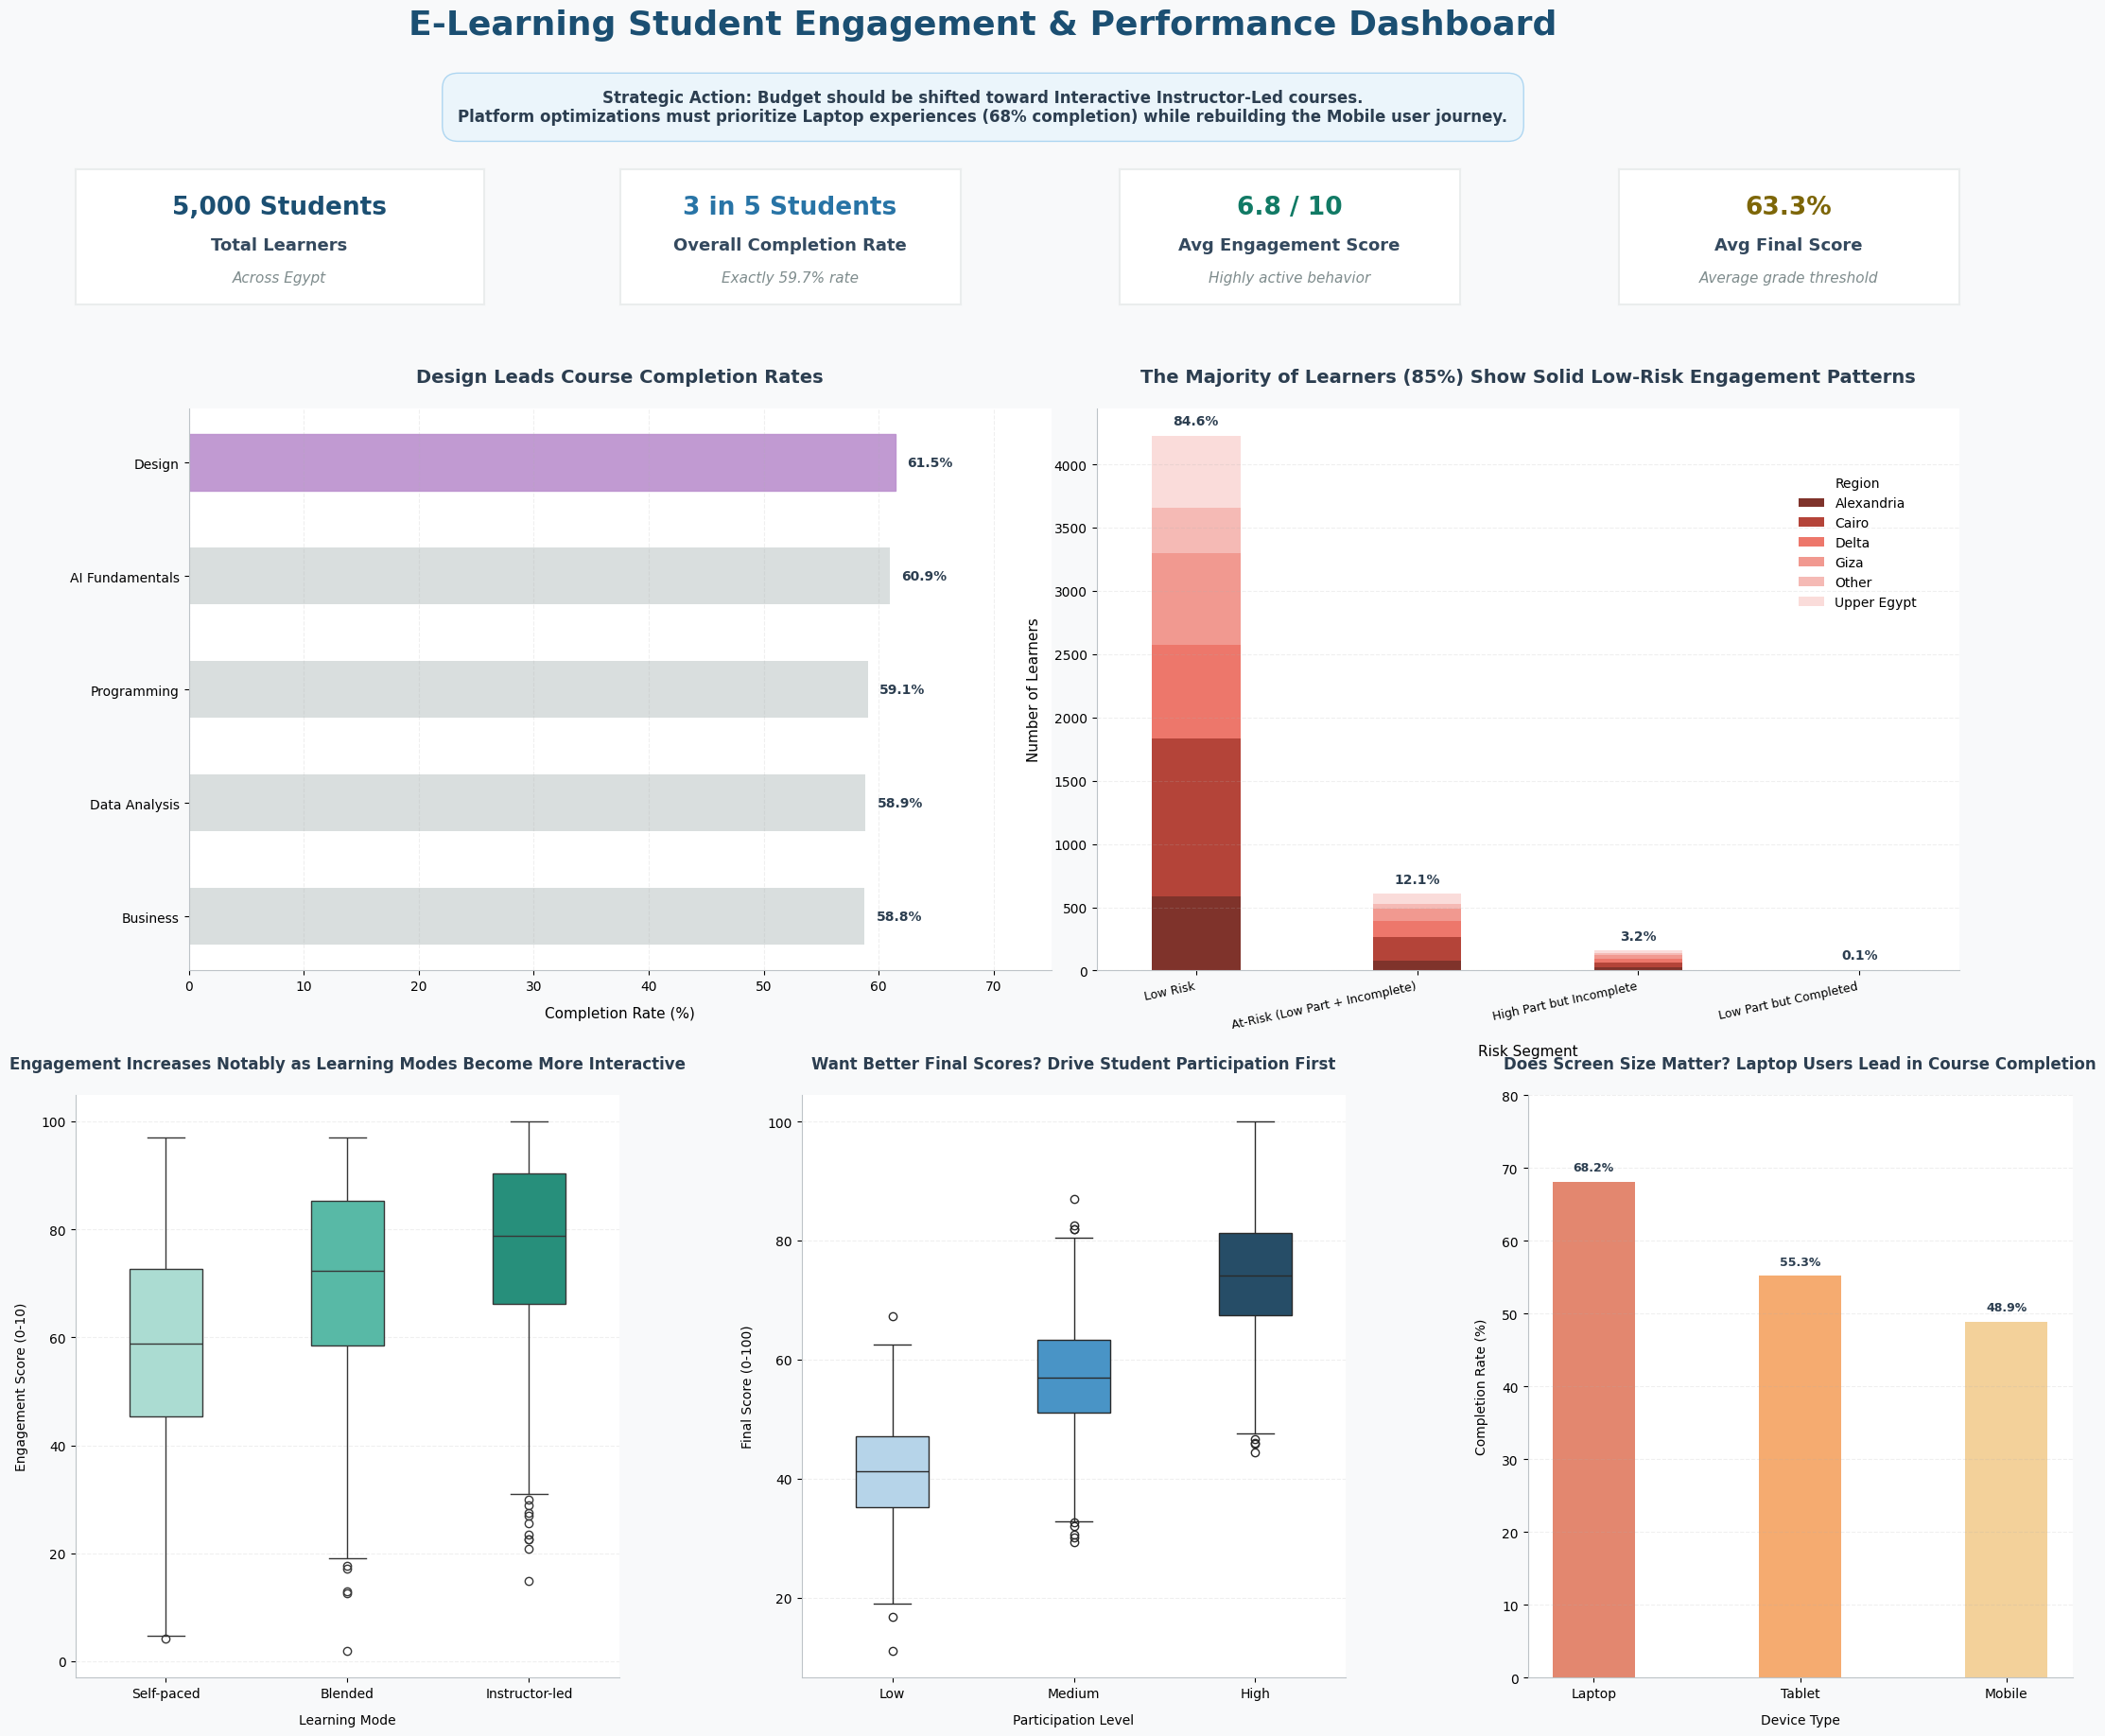

In [38]:
# CANVAS & GRID SETUP
fig = plt.figure(figsize=(24, 22), facecolor='#f8f9fa')

fig.text(0.5, 0.97, 'E-Learning Student Engagement & Performance Dashboard', 
         fontsize=26, weight='bold', color='#1b4f72', ha='center')

# Action Banner
action_text = "Strategic Action: Budget should be shifted toward Interactive Instructor-Led courses.\nPlatform optimizations must prioritize Laptop experiences (68% completion) while rebuilding the Mobile user journey."
fig.text(0.5, 0.935, action_text, fontsize=12, color='#2c3e50', weight='semibold',
         ha='center', va='center', bbox=dict(boxstyle="round,pad=1.0", fc='#ebf5fb', ec='#aed6f1', lw=1))


# KPI CARDS LAYOUT 
kpis = [
    {"label": "Total Learners", "val": "5,000 Students", "sub": "Across Egypt", "color": "#1b4f72"},
    {"label": "Overall Completion Rate", "val": "3 in 5 Students", "sub": "Exactly 59.7% rate", "color": "#2874a6"},
    {"label": "Avg Engagement Score", "val": "6.8 / 10", "sub": "Highly active behavior", "color": "#117a65"},
    {"label": "Avg Final Score", "val": "63.3%", "sub": "Average grade threshold", "color": "#7d6608"}
]

y_position = 0.84
card_height = 0.065
left_padding = 0.10  

for i, kpi in enumerate(kpis):
    if i == 0:
        card_width = 0.18    
        card_x = left_padding  
    else:
        card_width = 0.15    
        card_x = left_padding + 0.02 + i * 0.22  
        
    ax_kpi = fig.add_axes([card_x, y_position, card_width, card_height])
    
    ax_kpi.set_facecolor('#ffffff')
    for spine in ax_kpi.spines.values():
        spine.set_color('#eaeded')
        spine.set_linewidth(1.5)
        
    ax_kpi.text(0.5, 0.72, kpi["val"], fontsize=19, weight='bold', color=kpi["color"], ha='center', va='center')
    ax_kpi.text(0.5, 0.44, kpi["label"], fontsize=13, color='#34495e', ha='center', va='center', weight='bold')
    ax_kpi.text(0.5, 0.20, kpi["sub"], fontsize=11, color='#7f8c8d', ha='center', va='center', style='italic')
    
    ax_kpi.set_xticks([])
    ax_kpi.set_yticks([])


# FIRST ROW VISUALS 
plots_y = 0.52         
plots_height = 0.27    

# Plot 1: Course Completion Rate
ax1 = fig.add_axes([0.15, plots_y, 0.38, plots_height])

bars1 = ax1.barh(completion_by_course['course_type'], 
                  completion_by_course['completion_rate_%'],
                  color='#d5dbdb', alpha=0.9, height=0.5)
bars1[-1].set_color('#bb8fce')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#bdc3c7')
ax1.spines['bottom'].set_color('#bdc3c7')

ax1.set_title('Design Leads Course Completion Rates', fontsize=14, weight='bold',x=0.5, ha='center', pad=20, color='#2c3e50')
ax1.set_xlabel('Completion Rate (%)', fontsize=11, labelpad=10)
ax1.set_xlim(0, 75)
ax1.grid(True, alpha=0.2, axis='x', linestyle='--')

for bar in bars1:
    width = bar.get_width()
    ax1.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
             ha='left', va='center', fontsize=10, weight='semibold', color='#2c3e50')


# Plot 2: Risk Segments Stacked by Region
ax2 = fig.add_axes([0.55, plots_y, 0.38, plots_height])

risk_colors = ['#78281f', '#b03a2e', '#ec7063', '#f1948a', '#f5b7b1', '#fadbd8']
risk_region_table.plot(kind='bar', stacked=True, color=risk_colors, alpha=0.95, ax=ax2, width=0.4)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#bdc3c7')
ax2.spines['bottom'].set_color('#bdc3c7')

ax2.set_title('The Majority of Learners (85%) Show Solid Low-Risk Engagement Patterns', fontsize=14, weight='bold', pad=20, color='#2c3e50')
ax2.set_xlabel('Risk Segment', fontsize=11, labelpad=10)
ax2.set_ylabel('Number of Learners', fontsize=11, labelpad=10)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=12, ha='right', fontsize=9)
ax2.grid(True, alpha=0.2, axis='y', linestyle='--')

for i, (idx, row) in enumerate(risk_df.iterrows()):
    total_val = row['Count']
    pct = row['Percentage']
    ax2.text(i, total_val + 60, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, weight='bold', color='#2c3e50')

ax2.legend(title='Region', bbox_to_anchor=(0.8, 0.9), loc='upper left', frameon=False)


# SECOND ROW VISUALS 
row2_y = 0.18
row2_height = 0.28
plot_width = 0.24  
gap = 0.08

# Plot 3: Learning Mode Engagement
ax3 = fig.add_axes([left_padding, row2_y, plot_width, row2_height])
sns.boxplot(data=df, x='learning_mode', y='engagement_score', hue='learning_mode', legend=False,
            palette=['#48c9b0', '#a3e4d7', '#16a085'], 
            order=['Self-paced', 'Blended', 'Instructor-led'], ax=ax3, width=0.4)

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_color('#bdc3c7')
ax3.spines['bottom'].set_color('#bdc3c7')

ax3.set_title('Engagement Increases Notably as Learning Modes Become More Interactive', fontsize=12, weight='bold', pad=20, color='#2c3e50')
ax3.set_xlabel('Learning Mode', fontsize=10, labelpad=10)
ax3.set_ylabel('Engagement Score (0-10)', fontsize=10, labelpad=10)
ax3.grid(True, alpha=0.2, axis='y', linestyle='--')


# Plot 4: Participation vs Final Score
ax4 = fig.add_axes([left_padding + plot_width + gap, row2_y, plot_width, row2_height])
sns.boxplot(data=df, x='participation_level', y='final_score', hue='participation_level', legend=False,
            order=['Low', 'Medium', 'High'], palette=['#1b4f72', '#3498db', '#aed6f1'], ax=ax4, width=0.4)

ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.spines['left'].set_color('#bdc3c7')
ax4.spines['bottom'].set_color('#bdc3c7')

ax4.set_title('Want Better Final Scores? Drive Student Participation First', fontsize=12, weight='bold', pad=20, color='#2c3e50')
ax4.set_xlabel('Participation Level', fontsize=10, labelpad=10)
ax4.set_ylabel('Final Score (0-100)', fontsize=10, labelpad=10)
ax4.grid(True, alpha=0.2, axis='y', linestyle='--')


# Plot 5: Device Type vs Completion Rate
ax5 = fig.add_axes([left_padding + 2*(plot_width + gap), row2_y, plot_width, row2_height])
coral_colors = ['#e07a5f', '#f4a261', '#f2cc8f']
bars5 = ax5.bar(device_completion['device_type'], device_completion['completion_rate_%'], 
                color=coral_colors, alpha=0.9, width=0.4)

ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.spines['left'].set_color('#bdc3c7')
ax5.spines['bottom'].set_color('#bdc3c7')

ax5.set_title('Does Screen Size Matter? Laptop Users Lead in Course Completion', fontsize=12, weight='bold', pad=20, color='#2c3e50')
ax5.set_xlabel('Device Type', fontsize=10, labelpad=10)
ax5.set_ylabel('Completion Rate (%)', fontsize=10, labelpad=10)
ax5.set_ylim(0, 80)
ax5.grid(True, alpha=0.2, axis='y', linestyle='--')

for bar in bars5:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', 
             ha='center', va='bottom', fontsize=9, weight='bold', color='#2c3e50')

plt.subplots_adjust(bottom=0.08)
plt.savefig('EYOUTH-30811071801341_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()